<a href="https://colab.research.google.com/github/HurtovaAlina/ITStep-AI/blob/superwised_learning/Practice_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [33]:
import pandas as pd

In [34]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/car_price.csv")

In [35]:
df.head()

,mileage,age,engine,horsepower,num_previous_owners,price
0,60675,4,1.6,228,1,18421
1,23671,24,1.7,179,1,11279
2,82893,5,2.3,115,1,10279
3,94692,11,2.4,94,1,9876
4,12509,9,1.8,126,0,19428


# Опис даних

- **mileage** — пробіг автомобіля в кілометрах
- **age** — вік автомобіля в роках
- **engine** — об'єм двигуна автомобіля в літрах
- **horsepower** — потужність двигуна в кінських силах
- **num_previous_owners** — кількість попередніх власників автомобіля
- **price** — ціна автомобіля

Потрібно спрогнозувати **ціну** автомобіля

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [36]:
y = df['price']
X = df.drop(columns='price')

X.head()

,mileage,age,engine,horsepower,num_previous_owners
0,60675,4,1.6,228,1
1,23671,24,1.7,179,1
2,82893,5,2.3,115,1
3,94692,11,2.4,94,1
4,12509,9,1.8,126,0


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [37]:
# розділити данні на тренувальні та тестові
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42
                                                    )

X_train.shape, X_test.shape

((3808, 5), (952, 5))

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [38]:
from sklearn.tree import DecisionTreeRegressor


model_tree = DecisionTreeRegressor()

# натренувати модель
model_tree.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте ціну автомобіля для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [39]:
y_train_pred = model_tree.predict(X_train)
y_train_pred

array([ 9477.,  9844.,  7596., ...,  3772., 12724.,  6828.])

In [40]:
comparison = pd.DataFrame({
    'Справжня ціна': y_train,
    'Прогнозована ціна': y_train_pred
})

comparison.head(10)

,Справжня ціна,Прогнозована ціна
624,9477,9477.0
4522,9844,9844.0
4227,7596,7596.0
3135,21649,21649.0
1554,15417,15417.0
3456,20008,20008.0
3155,15723,15723.0
1739,12386,12386.0
4608,18777,18777.0
1730,10823,10823.0


In [41]:
# Метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.0
MSE: 0.0
R2: 1.0


# Завдання 5
Спронозуйте ціну автомобіля для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [42]:
# Прогноз ціни для тестових даних
y_test_pred = model_tree.predict(X_test)

# Порівняння справжньої та прогнозованої ціни
comparison = pd.DataFrame({
    'Справжня ціна': y_test,
    'Прогнозована ціна': y_test_pred
})

comparison.head(10)

,Справжня ціна,Прогнозована ціна
2314,17465,11901.0
315,13450,22056.0
2329,16224,14109.0
472,16753,23347.0
534,30033,31166.0
2451,21174,20230.0
4128,8152,5829.0
4326,14721,19107.0
1469,18558,20140.0
2771,21208,20687.0


In [43]:

# 1. Робимо прогноз для тестових даних
# MAE
mae = mean_absolute_error(y_test, y_test_pred)

# MSE
mse = mean_squared_error(y_test, y_test_pred)

# R2
r2 = r2_score(y_test, y_test_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 3006.7699579831933
MSE: 14060145.106092436
R2: 0.5486886717096395


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [48]:
train_mae = []
test_mae = []

max_depths = range(1,10)

for depth in max_depths:
    # Створюємо модель
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Навчаємо модель
    model.fit(X_train, y_train)

    # Прогноз для тренувальних даних
    y_train_pred = model.predict(X_train)

    # Прогноз для тестових даних
    y_test_pred = model.predict(X_test)

    # MAE для train
    train_mae.append(mean_absolute_error(y_train, y_train_pred))

    # MAE для test
    test_mae.append(mean_absolute_error(y_test, y_test_pred))

In [49]:
print("train_mae:", train_mae)
print("test_mae:", test_mae)

train_mae: [3988.062118176598, 3370.675497242045, 2923.2265611961425, 2616.6429313246977, 2428.453729478045, 2267.9994315482454, 2094.89873852778, 1917.0353092929756, 1729.781981722951]
test_mae: [3865.5684419801573, 3276.1329386307693, 2841.451556037191, 2582.0253313989588, 2434.323528219818, 2375.7342743904146, 2350.8905968716754, 2320.7344161372207, 2349.121374429182]


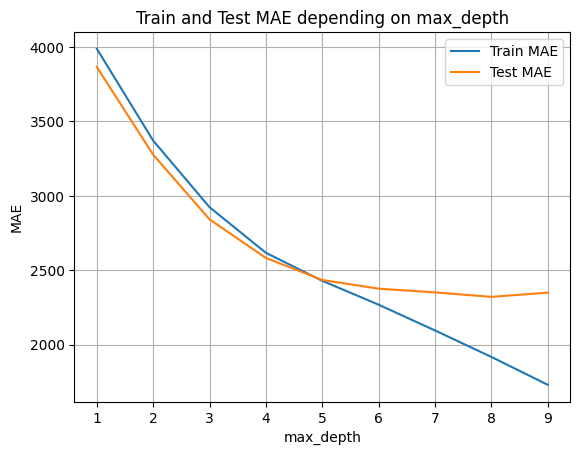

In [50]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [51]:
# оптимальне значення max_depth = 5
# будуємо дерево з max_depth = 5

model_tree = DecisionTreeRegressor(max_depth = 5)

# натренувати модель
model_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

In [54]:
# Прогноз для тренувальних даних

y_train_pred = model_tree.predict(X_train)
y_train_pred

array([ 8415.96363636, 16100.06756757,  7703.63218391, ...,
        4372.15      , 16100.06756757,  8415.96363636])

In [55]:
# Прогноз ціни для тестових даних
y_test_pred = model_tree.predict(X_test)

# Порівняння справжньої та прогнозованої ціни
comparison = pd.DataFrame({
    'Справжня ціна': y_test,
    'Прогнозована ціна': y_test_pred
})

comparison.head(10)

,Справжня ціна,Прогнозована ціна
2314,17465,16100.067568
315,13450,17181.696809
2329,16224,13265.329670
472,16753,17181.696809
534,30033,25544.407960
2451,21174,17181.696809
4128,8152,8415.963636
4326,14721,17334.390476
1469,18558,17181.696809
2771,21208,21034.871429


In [57]:
# MAE
mae = mean_absolute_error(y_test, y_test_pred)

# MSE
mse = mean_squared_error(y_test, y_test_pred)

# R2
r2 = r2_score(y_test, y_test_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 2434.323528219818
MSE: 9395824.679634908
R2: 0.698406944981532


# Завдання 8
Побудуйте такіж графіки для метрик MSE та R2

In [58]:
# MSE

train_mse = []
test_mse = []

max_depths = range(1,10)

for depth in max_depths:
    # Створюємо модель
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Навчаємо модель
    model.fit(X_train, y_train)

    # Прогноз для тренувальних даних
    y_train_pred = model.predict(X_train)

    # Прогноз для тестових даних
    y_test_pred = model.predict(X_test)

    # MAE для train
    train_mse.append(mean_squared_error(y_train, y_train_pred))

    # MAE для test
    test_mse.append(mean_squared_error(y_test, y_test_pred))

In [62]:
print("train_mse:", train_mse)
print("test_mse:", test_mse)

train_mse: [24865704.19274516, 17497756.639697827, 13298249.738738332, 10725884.058365183, 9309938.371494608, 8115165.110174416, 7044595.578268086, 6088536.7460520705, 5120751.13195015]
test_mse: [23348226.35079933, 16409452.185000427, 12869443.875461118, 10411550.874377279, 9395824.679634908, 8897367.454212854, 8880136.161695283, 8636027.06434134, 8755623.873545662]


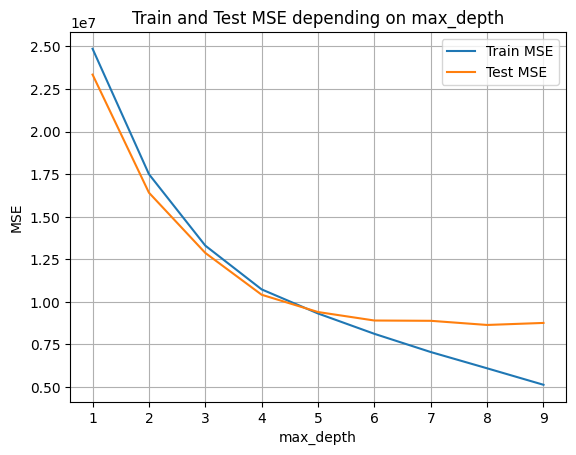

In [60]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mse, label="Train MSE")
plt.plot(max_depths, test_mse, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [61]:
# R2

train_R2 = []
test_R2 = []

max_depths = range(1,10)

for depth in max_depths:
    # Створюємо модель
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Навчаємо модель
    model.fit(X_train, y_train)

    # Прогноз для тренувальних даних
    y_train_pred = model.predict(X_train)

    # Прогноз для тестових даних
    y_test_pred = model.predict(X_test)

    # MAE для train
    train_R2.append(r2_score(y_train, y_train_pred))

    # MAE для test
    test_R2.append(r2_score(y_test, y_test_pred))

In [63]:
print("train_R2:", train_R2)
print("test_R2:", test_R2)

train_R2: [0.23351134374560067, 0.460629312153503, 0.5900796738443117, 0.6693731898638344, 0.7130199049717576, 0.7498489504916181, 0.7828493994464159, 0.8123200407733245, 0.8421521617197222]
test_R2: [0.2505540328287731, 0.4732791442585691, 0.5869085442599118, 0.6658035305310042, 0.698406944981532, 0.7144067366482394, 0.7149598374488062, 0.722795403877408, 0.7189565107213265]


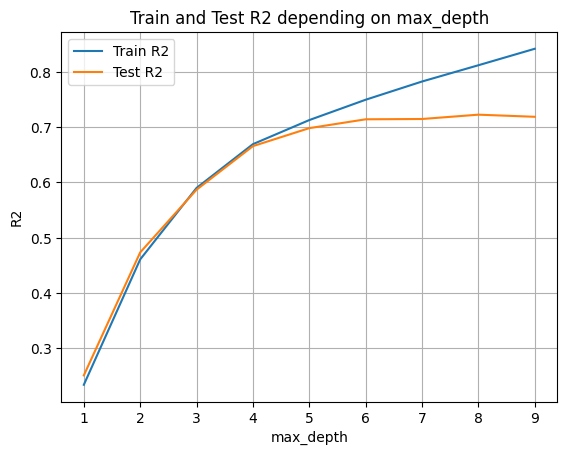

In [64]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_R2, label="Train R2")
plt.plot(max_depths, test_R2, label="Test R2")

plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Train and Test R2 depending on max_depth")
plt.legend()
plt.grid()

plt.show()